In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/10001
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.886839794224
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  37.59293969068204
RUN  2 , total integrated cost =  33.8574829671503
RUN  3 , total integrated cost =  28.464639783237182
RUN  4 , total integrated cost =  26.044325776318136
RUN  5 , total integrated cost =  22.354898110507197
RUN  6 , total integrated cost =  20.5777848079921
RUN  7 , total integrated cost =  17.659723877512086
RUN  8 , total integrated cost =  16.33301825936177
RUN  9 , total integrated cost =  13.721628270481675
RUN  10 , total integrated cost =  12.412346140555654
RUN  11 , total integrated cost =  10.938483046243105
RUN  12 , total integrated cost =  10.91335636909109
RUN  13 , total integrated cost =  10.88167999484503
RUN  14 , total integrated cost =  10.85138500656702
RUN  15 , total integrated cost =  10.748532639225775
RUN  16

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1962 , total integrated cost =  8.653464659309773
Improved over  1962  iterations in  212.84101708978415  seconds by  99.85339090606945  percent.
Problem in initial value trasfer:  Vmean_exc -62.79057410262651 -62.7893908533989
weight =  6820.859287716994
set cost params:  1.0 0.0 6820.859287716994
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5879.198330319998
Gradient descend method:  None
RUN  1 , total integrated cost =  5814.611932152175
RUN  2 , total integrated cost =  5814.605499660457
RUN  3 , total integrated cost =  5814.605065070712
RUN  4 , total integrated cost =  5814.602335632985
RUN  5 , total integrated cost =  5814.590025559713
RUN  6 , total integrated cost =  5814.587874618544
RUN  7 , total integrated cost =  5814.587430210245
RUN  8 , total integrated cost =  5814.57655768144
RUN  9 , total integrated cost =  5814.554282149306
RUN  10 , total integrated cost =  5814.55288297753
RUN  11 , total integr

ERROR:root:Problem in initial value trasfer


RUN  170 , total integrated cost =  5812.702459123392
Control only changes marginally.
RUN  171 , total integrated cost =  5812.702459123392
Improved over  171  iterations in  13.659945985302329  seconds by  1.131036366874639  percent.
Problem in initial value trasfer:  Vmean_exc -64.75893378354674 -64.76129438792985
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  119.83737487337429
RUN  2 , total integrated cost =  100.42541849854581
RUN  3 , total integrated cost =  75.06161377653356
RUN  4 , total integrated cost =  68.00702876434545
RUN  5 , total integrated cost =  60.257929861299615
RUN  6 , total integrated cost =  56.96886019257496
RUN  7 , total integrated cost =  53.26525415852987
RUN  8 , total integrated cost =  51.134485357405204
RUN  9 , total integrated cost =  48.98487983224432
RUN 

...

RUN  11 , total integrated cost =  14315.691123333429
Control only changes marginally.
RUN  11 , total integrated cost =  14315.691123333429
Improved over  11  iterations in  0.9099383559077978  seconds by  1.3295101171295016  percent.
Problem in initial value trasfer:  Vmean_exc -63.70896910062826 -63.75961925289114
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38613.011975189
Gradient descend method:  None
RUN  1 , total integrated cost =  210.64996174468658
RUN  2 , total integrated cost =  126.36305618642977
RUN  3 , total integrated cost =  71.22042068841824
RUN  4 , total integrated cost =  70.02924299860935
RUN  5 , total integrated cost =  68.99386088089105
RUN  6 , total integrated cost =  67.98946883118634
RUN  7 , total integrated cost =  67.12753905807106
RUN  8 , total integrated cost =  66.43759529538032
RUN  9 , total integrated cost =  66.03989642130578
RUN  10 , 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  241 , total integrated cost =  59.677660608122274
Improved over  241  iterations in  16.713128769770265  seconds by  99.84544676119421  percent.
Problem in initial value trasfer:  Vmean_exc -63.58697442328238 -63.59346301634883
weight =  6470.262336311098
set cost params:  1.0 0.0 6470.262336311098
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38152.91022921327
Gradient descend method:  None
RUN  1 , total integrated cost =  36749.23694612928
RUN  2 , total integrated cost =  36745.835079106546
RUN  3 , total integrated cost =  36744.28829323656
RUN  4 , total integrated cost =  36742.77069976314
RUN  5 , total integrated cost =  36741.84042255541
RUN  6 , total integrated cost =  36740.77385335167
RUN  7 , total integrated cost =  36739.93805393438
RUN  8 , total integrated cost =  36738.96700606836
RUN  9 , total integrated cost =  36738.17798716936
RUN  10 , total integrated cost =  36737.23520000524
RUN  11 , total int

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  535 , total integrated cost =  33517.27323175181
Improved over  535  iterations in  38.45621861703694  seconds by  12.15015308035926  percent.
Problem in initial value trasfer:  Vmean_exc -56.69285988146676 -56.69525299410493


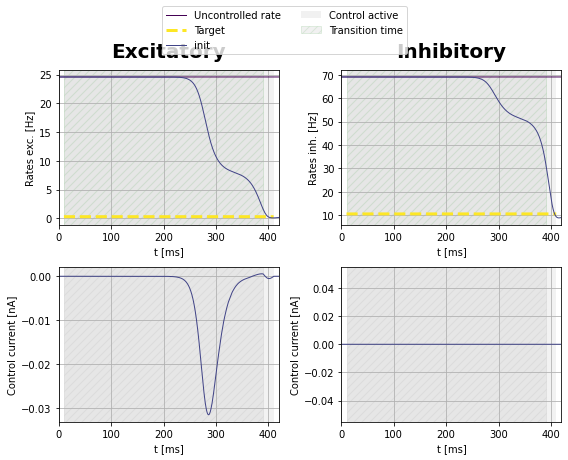

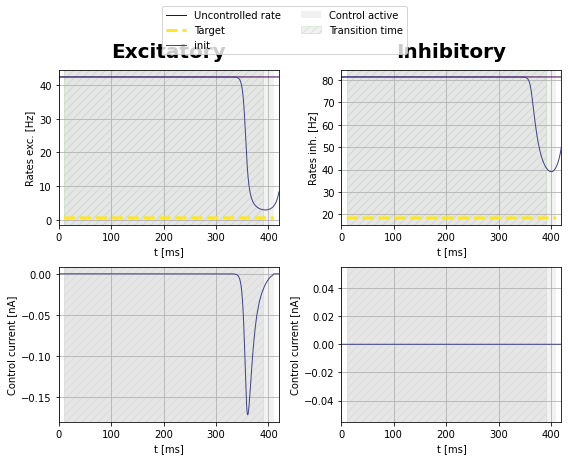

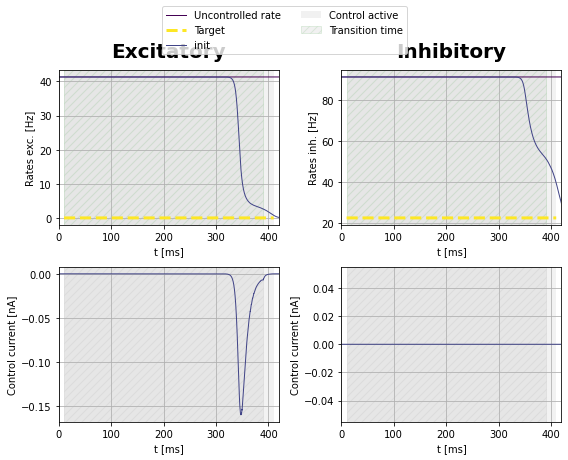

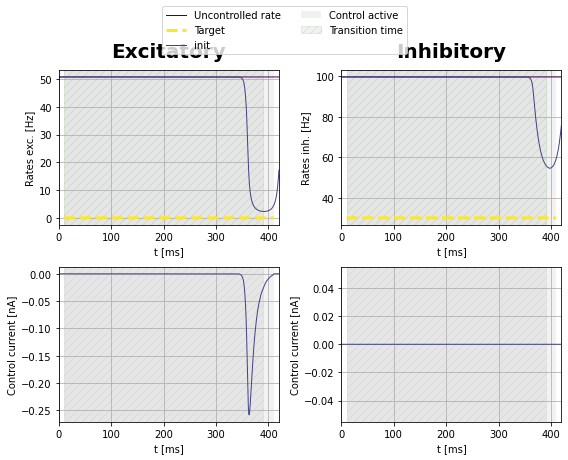

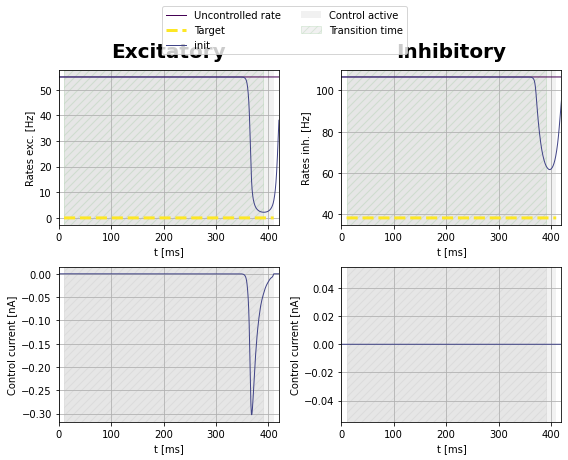

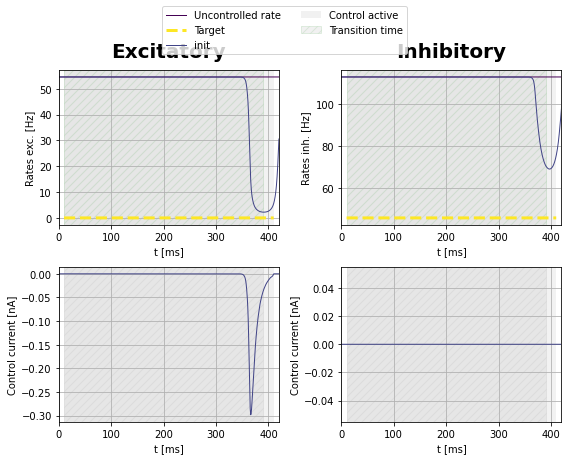

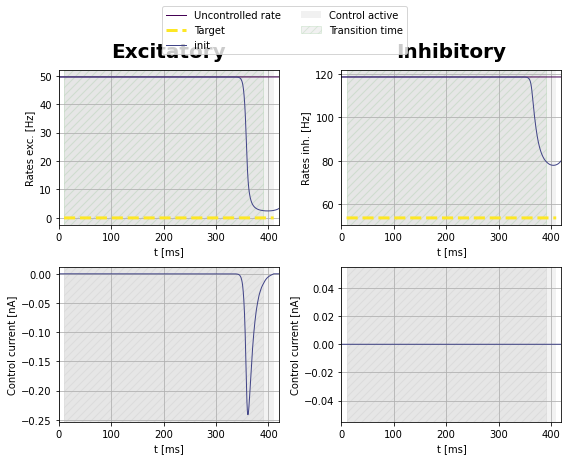

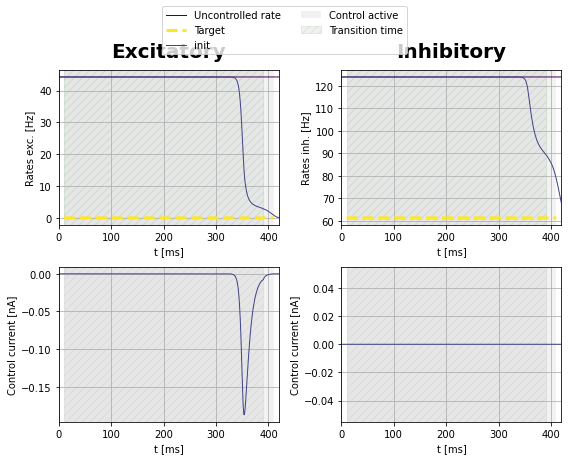

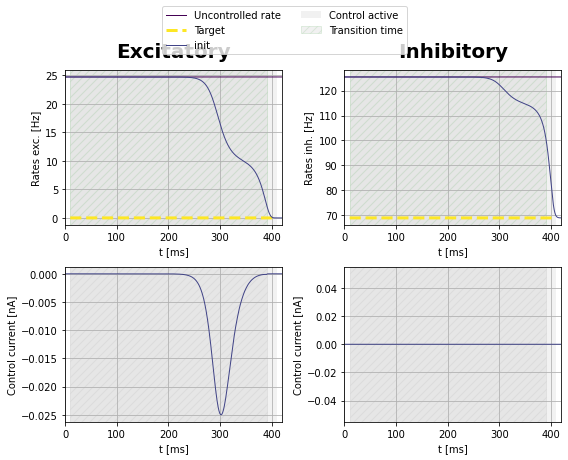

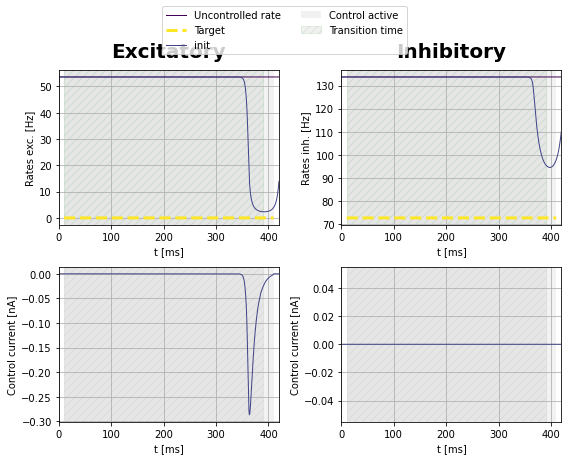

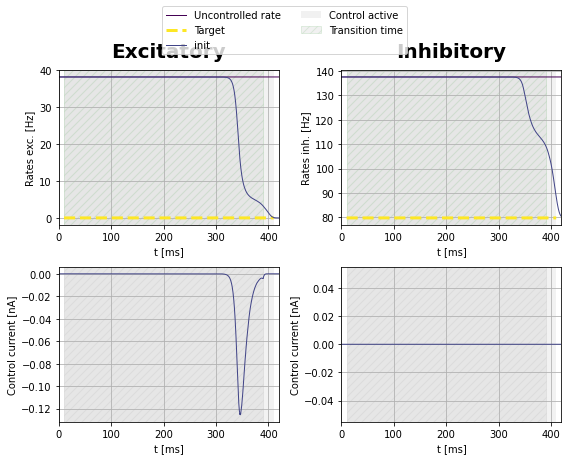

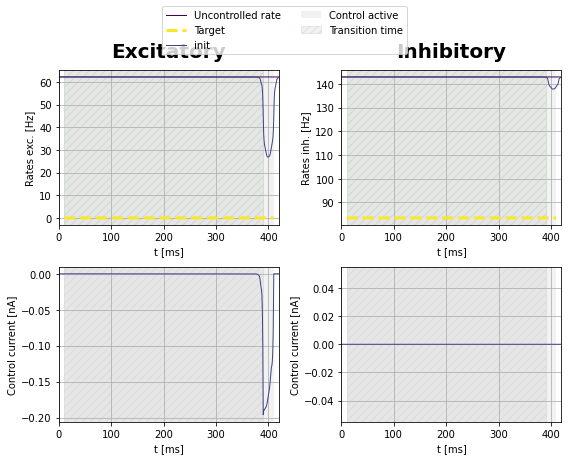

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  13 0.47500000000000014 0.40000000000000013
found solution for  13
-------  26 0.47500000000000014 0.4750000000000002
found so

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  263 , total integrated cost =  43.65047400549287
Improved over  263  iterations in  20.531787559390068  seconds by  99.82829056145519  percent.
Problem in initial value trasfer:  Vmean_exc -64.63368961862109 -64.64267935621544
weight =  5901.354085481862
set cost params:  1.0 0.0 5901.354085481862
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  25536.116096404316
Gradient descend method:  None
RUN  1 , total integrated cost =  24792.57964245058
RUN  2 , total integrated cost =  24784.909173754582
RUN  3 , total integrated cost =  24766.36758541208
RUN  4 , total integrated cost =  24765.863317365507
RUN  5 , total integrated cost =  24765.861185915706
RUN  6 , total integrated cost =  24765.86113130225
RUN  7 , total integrated cost =  24765.861126742584
RUN  8 , total integrated cost =  24765.86112377247
RUN  9 , total integrated cost =  24765.861121345406
RUN  10 , total integrated cost =  24765.86111903858
RUN  11 , total

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  37 , total integrated cost =  24765.806945664757
Improved over  37  iterations in  3.2254885490983725  seconds by  3.0165478095082108  percent.
Problem in initial value trasfer:  Vmean_exc -57.98299088013021 -57.969776159591575
-------  52 0.5500000000000003 0.5750000000000003
[0, 13, 26] []
closest index  26
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  29857.363103049272
Gradient descend method:  None
RUN  1 , total integrated cost =  176.71586424865922
RUN  2 , total integrated cost =  137.78512709122296
RUN  3 , total integrated cost =  63.49538817879973
RUN  4 , total integrated cost =  61.40415809858287
RUN  5 , total integrated cost =  60.35458725014652
RUN  6 , total integrated cost =  59.63186116136665
RUN  7 , total integrated cost =  59.201901640186314
RUN  8 , total integrated cost =  58.79499759841547
RUN  9 , total integrated cost =  58.52915588465612
RUN  

...

Control only changes marginally.
RUN  36 , total integrated cost =  28809.93540144069
Improved over  36  iterations in  3.0149844009429216  seconds by  3.563579348877127  percent.
Problem in initial value trasfer:  Vmean_exc -57.44190966591737 -57.422696348338896
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006
[0, 13, 26, 78, 91, 104, 117, 130, 39, 65] [117, 130, 91, 104, 78, 65, 39, 26, 13]
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38582.27139141889
Gradient descend method:  None
RUN  1 , total integrated cost =  227.5915706052306
RUN  2 , total integrated cost =  83.93092745271957
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  257 , total integrated cost =  59.71687537843661
Improved over  257  iterations in  31.185226161032915  seconds by  99.84522198091292  percent.
Problem in initial value trasfer:  Vmean_exc -63.58002192842057 -63.58650383041648
weight =  6466.013456077763
set cost params:  1.0 0.0 6466.013456077763
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38144.28751166183
Gradient descend method:  None
RUN  1 , total integrated cost =  36715.760655962935
RUN  2 , total integrated cost =  36688.71574154879
RUN  3 , total integrated cost =  36671.229436215996
RUN  4 , total integrated cost =  36651.18750842794
RUN  5 , total integrated cost =  36651.11336208869
RUN  6 , total integrated cost =  36651.065905029725
RUN  7 , total integrated cost =  36650.98873394291
RUN  8 , total integrated cost =  36650.97981796238
RUN  9 , total integrated cost =  36647.98172089386
RUN  10 , total integrated cost =  36647.38675691169
RUN  11 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  523 , total integrated cost =  33501.71288907501
Improved over  523  iterations in  59.61508807167411  seconds by  12.171087534843721  percent.
Problem in initial value trasfer:  Vmean_exc -56.693042786754525 -56.69541335974366
------------------------------------------------------------
-------------------- 10
------------------------------------------------------------
found solution:  [0, 13, 26, 78, 91, 104, 117, 130, 39, 65]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
closest index  -1
set cost params:  1.0 0.0 10.0
all options tried already
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6925.121599533168
set cost params:  1.0 0.0 6925.121599533168
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.521978081638
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.52196790264
RUN  2 , total integrated cost =  5901.521963463343
RUN  3 , total integrated cost =  5901.521953190246
RUN  4 , total integrated cost =  5901.521953190228
RUN  5 , total integrated cost =  5901.521953190226


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5901.521953190226
Control only changes marginally.
RUN  6 , total integrated cost =  5901.521953190226
Improved over  6  iterations in  1.2018670942634344  seconds by  4.2177953218924813e-07  percent.
Problem in initial value trasfer:  Vmean_exc -64.75824073426219 -64.76069172199922
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  5591.1813640615055
set cost params:  1.0 0.0 5591.1813640615055
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17545.80752266269
Gradient descend method:  None
RUN  1 , total integrated cost =  17545.79837920119
RUN  2 , total integrated cost =  17545.79837245145
RUN  3 , total integrated cost =  17545.79837245144
RUN  4 , total integrated cost =  17545.798372451434
RUN  5 , total integrated cost =  17545.79837245143
RUN  6 , total integrated cost =  17545.798372451427


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  17545.798372451427
Control only changes marginally.
RUN  7 , total integrated cost =  17545.798372451427
Improved over  7  iterations in  1.2979976832866669  seconds by  5.2150413992535505e-05  percent.
Problem in initial value trasfer:  Vmean_exc -58.154768792589664 -58.14723694640155
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  5853.815445840155
set cost params:  1.0 0.0 5853.815445840155
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17065.327810547187
Gradient descend method:  None
RUN  1 , total integrated cost =  17065.324756070604
RUN  2 , total integrated cost =  17065.324685636973
RUN  3 , total integrated cost =  17065.32467354558
RUN  4 , total integrated cost =  17065.324669953177
RUN  5 , total integrated cost =  17065.324669872407
RUN  6 , total integrated cost =  17065.3246698724


...

RUN  4 , total integrated cost =  38595.21986429485
Control only changes marginally.
RUN  4 , total integrated cost =  38595.21986429485
Improved over  4  iterations in  0.505742633715272  seconds by  1.576794615232302e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.701220312885006 -56.70112705455798
[[True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
no convergence
weight =  8382.204300236352
set cost params:  1.0 0.0 8382.204300236352
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30177.78186937008
Gradient d

ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  30177.77254207558
Control only changes marginally.
RUN  4 , total integrated cost =  30177.77254207558
Improved over  4  iterations in  0.49079098738729954  seconds by  3.090781999048886e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70435889199871 -56.7043730872232
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
no convergence
weight =  9025.90092688103
set cost params:  1.0 0.0 9025.90092688103
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38595.939322046324
Gradient descend method:  None
RUN  1 , t

ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  38595.934665855006
Control only changes marginally.
RUN  5 , total integrated cost =  38595.934665855006
Improved over  5  iterations in  0.9562479089945555  seconds by  1.2063940928896955e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70120819468151 -56.70111616048792


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10.654017803074506
Gradient descend method:  None
RUN  1 , total integrated cost =  8.653811422855172
RUN  2 , total integrated cost =  8.653661183756306
RUN  3 , total integrated cost =  8.653656948873179
RUN  4 , total integrated cost =  8.653656256179726
RUN  5 , total integrated cost =  8.653656052384205
RUN  6 , total integrated cost =  8.653655332714948
RUN  7 , total integrated cost =  8.653578781770644
RUN  8 , total integrated cost =  8.653390969991579
RUN  9 , total integrated cost =  8.653387333329043
RUN  10 , total integrated cost =  8.65338639855489
RUN  11 , total integrated cost =  8.653386249454952
RUN  12 , total integrated cost =  8.653385864269948
RUN  13 , total integrated cost =  8.653324913366836
RUN  14 , total integrated cost =  8.653153725503579
RUN  15 , total integrated cost =  8.653148640511406
RUN  16 , tot

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  37 , total integrated cost =  8.652328928913407
Improved over  37  iterations in  21.355815559625626  seconds by  18.788112721038047  percent.
Problem in initial value trasfer:  Vmean_exc -62.7831242740043 -62.781910234807086
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  86.20715483316295
Gradient descend method:  HS
RUN  1 , total integrated cost =  85.58551395628231
RUN  2 , total integrated cost =  85.55853800243644
RUN  3 , total integrated cost =  85.55637388424789
RUN  4 , total integrated cost =  85.55637388424772
RUN  5 , total integrated cost =  85.55637121723596
RUN  6 , total integrated cost =  85.55234350350811
RUN  7 , total integrated cost =  85.55132055656952
RUN  8 , total integrated cost =  85.55117004373658
RUN  9 , total integrated cost =  85.5511596980961
RUN  10 , total integrated cost =  85.55115967912852
RUN  11 , total integrated cost =  85.5511596564834

ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  85.55115965546699
Control only changes marginally.
RUN  16 , total integrated cost =  85.55115965546699
Improved over  16  iterations in  7.495907744392753  seconds by  0.7609521262655079  percent.
Problem in initial value trasfer:  Vmean_exc -64.38003970248732 -64.3697130111497
weight =  6898.271153083898
set cost params:  1.0 0.0 6898.271153083898
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5881.257206947956
Gradient descend method:  None
RUN  1 , total integrated cost =  5876.840196442914
RUN  2 , total integrated cost =  5876.835251862205
RUN  3 , total integrated cost =  5876.835227888008
RUN  4 , total integrated cost =  5876.835227520552
RUN  5 , total integrated cost =  5876.835227494722
RUN  6 , total integrated cost =  5876.835227492384
RUN  7 , total integrated cost =  5876.835227492182
RUN  8 , total integrated cost =  5876.8352274921535
RUN  9 , total integrated cost =  5876.835227492153


...

Control only changes marginally.
RUN  307 , total integrated cost =  59.658736601788476
Improved over  307  iterations in  119.36703871563077  seconds by  99.83686675040413  percent.
Problem in initial value trasfer:  Vmean_exc -63.59924301782958 -63.60572061431456
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  590.2353909791813
Gradient descend method:  HS
RUN  1 , total integrated cost =  582.5351904165984
RUN  2 , total integrated cost =  582.1967534356886
RUN  3 , total integrated cost =  582.196627732796
RUN  4 , total integrated cost =  582.1965873433118
RUN  5 , total integrated cost =  582.1965859917856
RUN  6 , total integrated cost =  582.1964498857371
RUN  7 , total integrated cost =  582.1964340660469
RUN  8 , total integrated cost =  582.1964337054278
RUN  9 , total integrated cost =  582.1964337031336


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  582.1964337031336
Control only changes marginally.
RUN  10 , total integrated cost =  582.1964337031336
Improved over  10  iterations in  3.713444272056222  seconds by  1.36199174073775  percent.
Problem in initial value trasfer:  Vmean_exc -61.40432756193108 -61.40543243688654
weight =  6631.299639760086
set cost params:  1.0 0.0 6631.299639760086
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38261.10867893508
Gradient descend method:  None
RUN  1 , total integrated cost =  37620.01781662551
RUN  2 , total integrated cost =  37617.832835932924
RUN  3 , total integrated cost =  37617.18383201885
RUN  4 , total integrated cost =  37616.48437425506
RUN  5 , total integrated cost =  37616.139501408645
RUN  6 , total integrated cost =  37615.70988056565
RUN  7 , total integrated cost =  37615.463885763165
RUN  8 , total integrated cost =  37615.174749861006
RUN  9 , total integrated cost =  37614.9764867921
RUN  10 , total integr

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  538 , total integrated cost =  34093.408527181426
Improved over  538  iterations in  225.7789514027536  seconds by  10.892784594211747  percent.
Problem in initial value trasfer:  Vmean_exc -56.69569986014215 -56.697696332411816


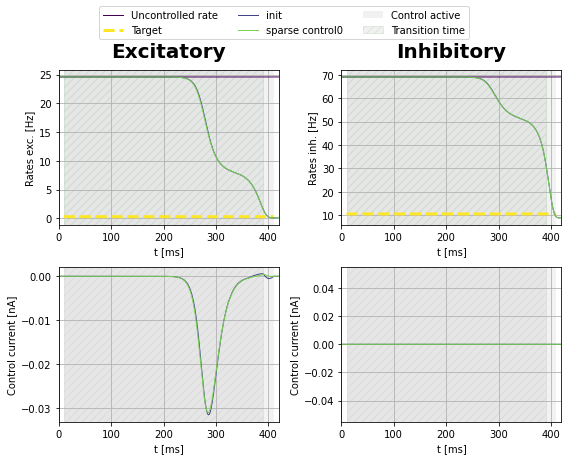

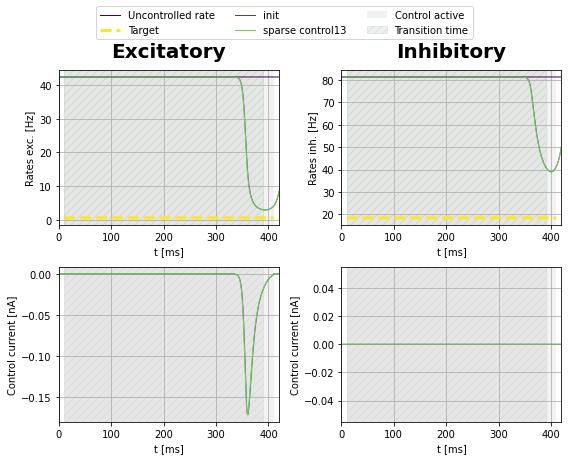

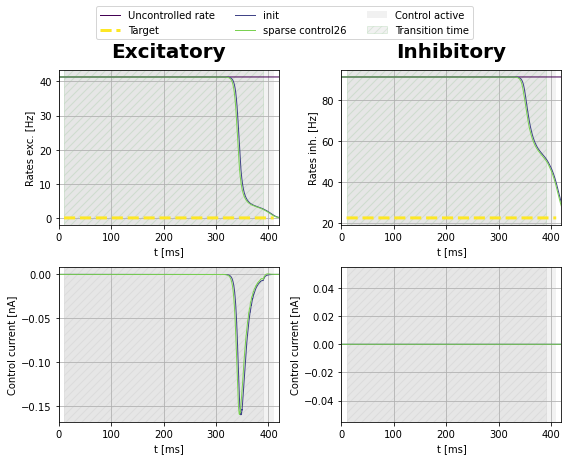

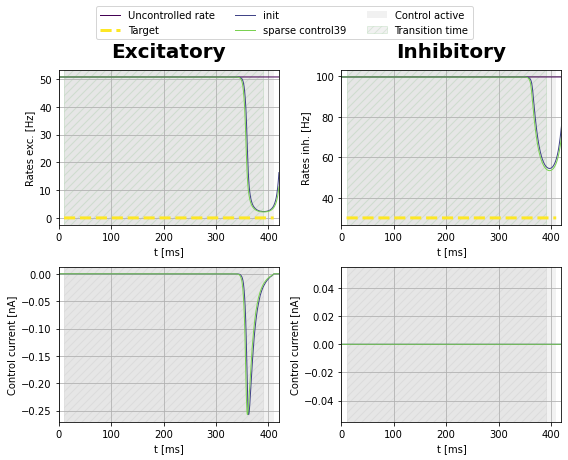

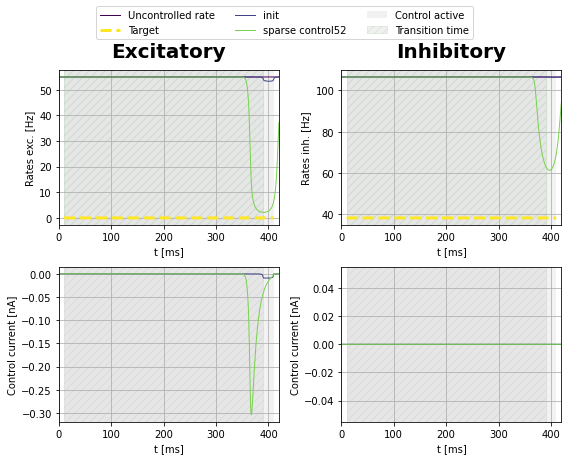

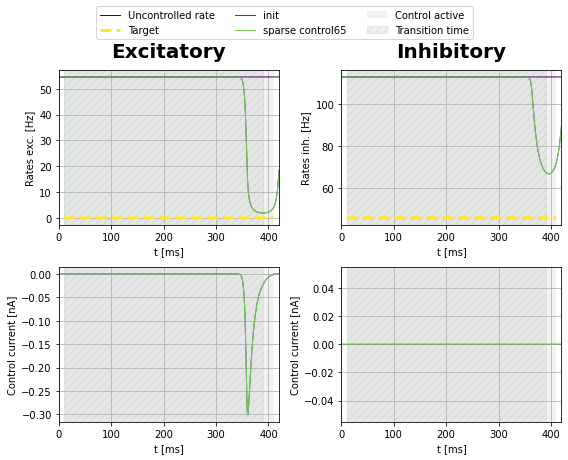

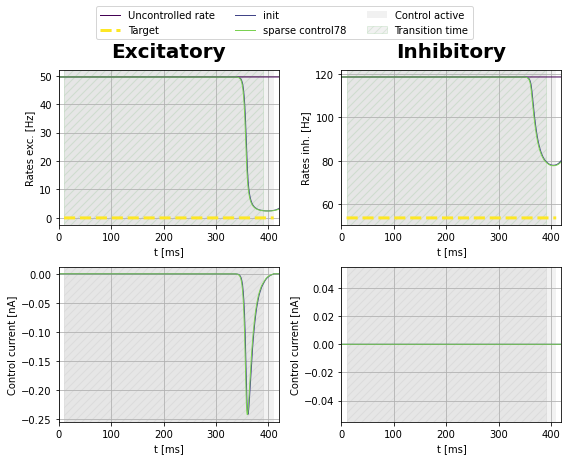

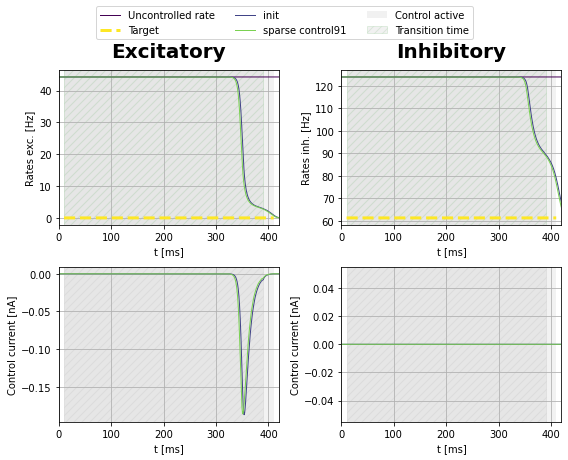

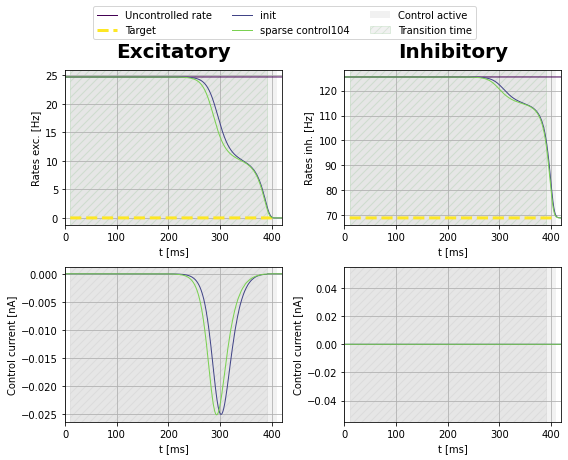

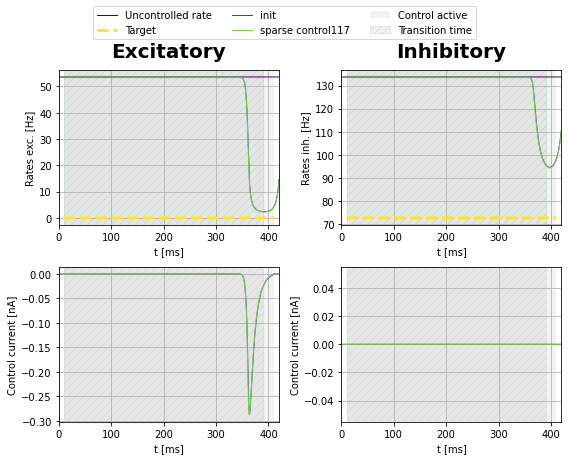

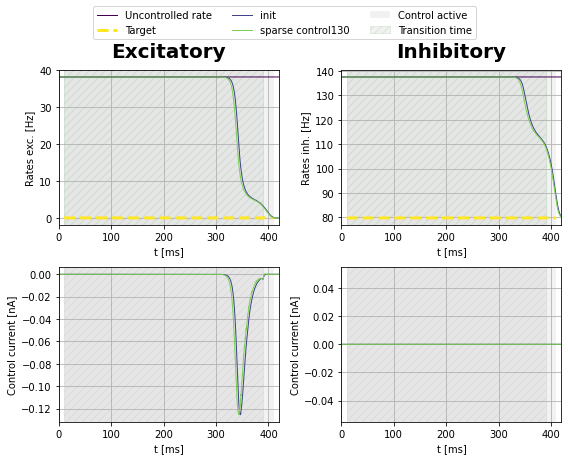

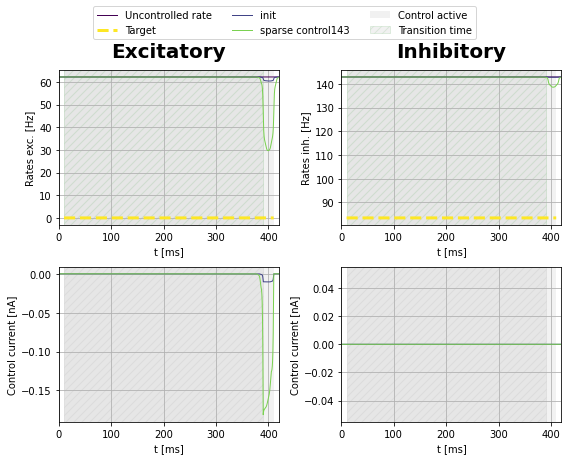

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6927.286870973022
set cost params:  1.0 0.0 6927.286870973022
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.545906506259
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.545902885933
RUN  2 , total integrated cost =  5901.545902885929


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  5901.545902885929
Control only changes marginally.
RUN  3 , total integrated cost =  5901.545902885929
Improved over  3  iterations in  1.440593557432294  seconds by  6.134544605629344e-08  percent.
Problem in initial value trasfer:  Vmean_exc -64.73588616518836 -64.73817786294123
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  5590.940383325634
set cost params:  1.0 0.0 5590.940383325634
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17546.637016611814
Gradient descend method:  None
RUN  1 , total integrated cost =  17546.62974845318
RUN  2 , total integrated cost =  17546.629672073286
RUN  3 , total integrated cost =  17546.629669995116
RUN  4 , total integrated cost =  17546.62966731961
RUN  5 , total integrated cost =  17546.629662365616
RUN  6 , total integrated cost =  17546.62964916134
RUN  7 , total integrated cost =  17546.629647520505
RUN  8 , total integrated cost =  17546.629647519076
RU

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  17546.629647519057
Control only changes marginally.
RUN  12 , total integrated cost =  17546.629647519057
Improved over  12  iterations in  4.414495434612036  seconds by  4.1997180147745894e-05  percent.
Problem in initial value trasfer:  Vmean_exc -58.13389085601566 -58.12616931613263
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  5856.832644158076
set cost params:  1.0 0.0 5856.832644158076
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17065.725495743736
Gradient descend method:  None
RUN  1 , total integrated cost =  17065.725132326366
RUN  2 , total integrated cost =  17065.725117956237
RUN  3 , total integrated cost =  17065.72511696978
RUN  4 , total integrated cost =  17065.725116969774


...

RUN  4 , total integrated cost =  38602.06719610534
Control only changes marginally.
RUN  4 , total integrated cost =  38602.06719610534
Improved over  4  iterations in  3.0325875133275986  seconds by  5.467264500680358e-06  percent.
Problem in initial value trasfer:  Vmean_exc -56.70107395108821 -56.70099556293951
--------------- 51
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.50

ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  38602.318389591564
Control only changes marginally.
RUN  5 , total integrated cost =  38602.318389591564
Improved over  5  iterations in  3.577280141413212  seconds by  0.00012292129291324727  percent.
Problem in initial value trasfer:  Vmean_exc -56.700955500807154 -56.70088545714709
--------------- 52
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  38602.55962831762
Control only changes marginally.
RUN  1 , total integrated cost =  38602.55962831762
Improved over  1  iterations in  0.894394176080823  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700955500807154 -56.70088545714709
--------------- 53
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.9077589814590157
Gradient descend method:  None
RUN  1 , total integrated cost =  0.8854851039347866
RUN  2 , total integrated cost =  0.885208340692975
RUN  3 , total integrated cost =  0.8848366562278741
RUN  4 , total integrated cost =  0.8845494031160078
RUN  5 , total integrated cost =  0.8840841693232586
RUN  6 , total integrated cost =  0.8836757969443175
RUN  7 , total integrated cost =  0.8829701317523526
RUN  8 , total integrated cost =  0.8822699157795277
RUN  9 , total integrated cost =  0.8800750855423554
RUN  10 , total integrated cost =  0.877557939656361
RUN  11 , total integrated cost =  0.8771056332206226
RUN  12 , total integrated cost =  0.8766414372855531
RUN  13 , total integrated cost =  0.8758873667709237
RUN  14 , total integrated cost =  0.8751092299242276
RUN  15 , total integrated cost =  0.8742084110043785


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  372 , total integrated cost =  0.8674324817931698
Improved over  372  iterations in  30.82574169524014  seconds by  70.16835001373046  percent.
Problem in initial value trasfer:  Vmean_exc -62.967498264869526 -62.9678327745968
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  75.46734435929723
Gradient descend method:  None
RUN  1 , total integrated cost =  3.6194904250612976
RUN  2 , total integrated cost =  3.6140753983425893
RUN  3 , total integrated cost =  3.6067116950016884
RUN  4 , total integrated cost =  3.6010666592787954
RUN  5 , total integrated cost =  3.5916158511189726
RUN  6 , total integrated cost =  3.5836995122951265
RUN  7 , total integrated cost =  3.558344632104609
RUN  8 , total integrated cost =  3.5314919343428333
RUN  9 , total integrated cost =  3.3032321882985216
RUN  10 , total integrated cost =  3.2712207892133156
RU

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  138 , total integrated cost =  3.2538914973185586
Improved over  138  iterations in  13.988473815843463  seconds by  95.68834503858132  percent.
Problem in initial value trasfer:  Vmean_exc -61.65971949739905 -61.65957639078468
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30.68222669179757
Gradient descend method:  None
RUN  1 , total integrated cost =  2.988354420762259
RUN  2 , total integrated cost =  2.9883075806826915
RUN  3 , total integrated cost =  2.9882962682874
RUN  4 , total integrated cost =  2.988090405116118
RUN  5 , total integrated cost =  2.9879720990905163
RUN  6 , total integrated cost =  2.987965952495275
RUN  7 , total integrated cost =  2.987598627548353
RUN  8 , total integrated cost =  2.9872123317312114
RUN  9 , total integrated cost =  2.987206764210316
RUN  10 , total integrated cost =  2.9871999042478303
RUN  11 ,

...

Control only changes marginally.
RUN  95 , total integrated cost =  4.68487173454284
Improved over  95  iterations in  6.90616818331182  seconds by  94.23501848360999  percent.
Problem in initial value trasfer:  Vmean_exc -67.44955748249691 -67.46384090104026
-------  130 0.47500000000000014 0.8500000000000005
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  26.132705397633657
Gradient descend method:  None
RUN  1 , total integrated cost =  2.4242199007343417
RUN  2 , total integrated cost =  2.4241664426318015
RUN  3 , total integrated cost =  2.424166157676298
RUN  4 , total integrated cost =  2.42416608521029
RUN  5 , total integrated cost =  2.4241660119763324
RUN  6 , total integrated cost =  2.424165900525838
RUN  7 , total integrated cost =  2.4241654570027027
RUN  8 , total integrated cost =  2.42103355933743
RUN  9 , total integrated cost =  2.4209874357677754
RUN  10 , total integrated cost =  2.420986005248645
RUN  11 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  73 , total integrated cost =  2.4186440032161536
Improved over  73  iterations in  5.300335692241788  seconds by  90.74476229531457  percent.
Problem in initial value trasfer:  Vmean_exc -72.55899593927575 -72.58637922531625
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37154.51345346021
Gradient descend method:  None
RUN  1 , total integrated cost =  23.142559311849595
RUN  2 , total integrated cost =  9.666871083049115
RUN  3 , total integrated cost =  9.32353728527859
RUN  4 , total integrated cost =  8.950327074338947
RUN  5 , total integrated cost =  8.736949317997112
RUN  6 , total integrated cost =  8.502803500789975
RUN  7 , total integrated cost =  8.336227135897992
RUN  8 , total integrated cost =  8.18093242583535
RUN  9 , total integrated cost =  8.065300745210745
RUN  10 , total integrated cost =  7.955484269241566
RUN  11 , total

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  310 , total integrated cost =  6.019036985713146
Improved over  310  iterations in  22.27879356406629  seconds by  99.98379998437268  percent.
Problem in initial value trasfer:  Vmean_exc -65.02996127382855 -65.03368406072724


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.8674324817931698
Gradient descend method:  None
RUN  1 , total integrated cost =  0.8674324817931698
Control only changes marginally.
RUN  1 , total integrated cost =  0.8674324817931698
Improved over  1  iterations in  0.18164096400141716  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -62.967498264869526 -62.9678327745968
-------  13 0.47500000000000014 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.2538914973185586
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.2538914973185586
Control only changes marginally.
RUN  1 , total integrated cost =  3.2538914973185586
Improved over  1  iterations in  0.30096722207963467  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -61.65971949739905 -61.65957639078468
-------  26 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.985139917889018
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  4.68487173454284
Control only changes marginally.
RUN  1 , total integrated cost =  4.68487173454284
Improved over  1  iterations in  0.3068243879824877  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -67.44955748249691 -67.46384090104026
-------  130 0.47500000000000014 0.8500000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.4186440032161536
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.4186440032161536
Control only changes marginally.
RUN  1 , total integrated cost =  2.4186440032161536
Improved over  1  iterations in  0.24073578603565693  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -72.55899593927575 -72.58637922531625
-------  143 0.6000000000000003 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6.019036985713146
Gradient descend method:  None
RUN  1 , total integrated cost =  6.019036985713146
Control only changes marginally.


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  6.019036985713146
Improved over  1  iterations in  0.17881843447685242  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.02996127382855 -65.03368406072724
--------------- 12
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
